In [15]:
import numpy as np
import matplotlib.pyplot as plt

# define constants
hbar = 1.054571817e-34 # J⋅s
e = 1.60218e-19 # C
eps_0 = 8.8541878188e-12 # C2⋅kg−1⋅m−3⋅s2
m_e = 9.1093837e-31 # kg
a = 0.529e-10 # m

In [56]:
# define the energy function
def E(n,Joules=True):
    energy = -(m_e / (2 * hbar**2) * (e**2 / (4 * np.pi * eps_0))**2) / n**2
    if Joules == True:
        return energy # J
    else:
        return energy / e # conversion from J to eV

def f(w, r, energy, l):
    u = w[0]
    v = w[1]
    # energy = E(n)

    alpha = (2 * m_e * e**2) / (4 * np.pi * hbar**2 * eps_0)
    beta = 2 * m_e * energy / hbar**2
    K = l*(l+1) / r**2 - alpha / r - beta

    fu = v
    fv = K * u

    return np.array([fu,fv])
print(E(1))

-2.179890679207151e-18


-0.0004200770191886818
0.0002561162881334369


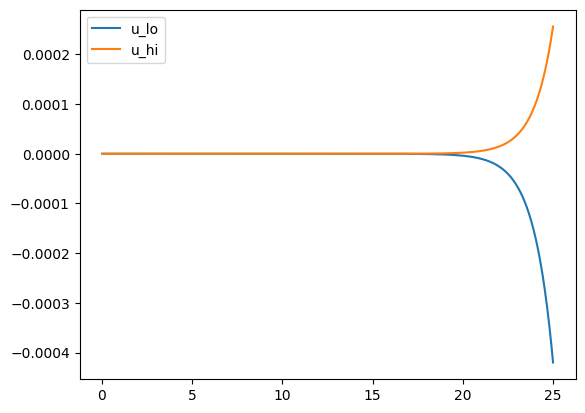

-0.5000000000000006


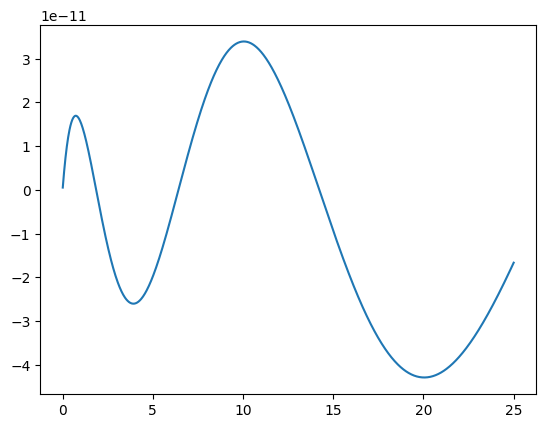

In [65]:
# quantum numbers
n = 1
l = 0

# discretize r
r_i = a/100
r_f = 25 * a
n_steps = 1001
h = (r_f - r_i) / n_steps

r = np.linspace(r_i,r_f,n_steps)

def RK4(r, E, l):
    u = np.zeros(n_steps)
    u[0] = r_i
    v = np.zeros(n_steps)
    v[0] = 1
    w = np.array([u[0],v[0]])
    
    # implement RK-4
    for i in range(n_steps-1):
        k1 = f(w,r[i],E,l)
        k2 = f(w+k1*h/2, r[i]+h/2,E,l)
        k3 = f(w+k2*h/2, r[i]+h/2,E,l)
        k4 = f(w+k3*h, r[i]+h,E,l)
    
        w = w + h*(k1+2*k2+2*k3+k4)/6
    
        u[i+1] = w[0]
        v[i+1] = w[1]

    return u

def shoot(r, E_lo, E_hi, tol=1e-8, max_iter=100):
    for i in range(max_iter):
        E_mid = (E_hi-E_lo)/2
        u_lo = RK4(r,E_lo,l)
        u_hi = RK4(r,E_hi,l)
        u_mid = RK4(r,E_mid,l)

        if u_lo[-1]*u_hi[-1]>0:
            E_lo = E_mid
        else:
            E_hi = E_mid

        if abs(u_mid[-1]) < tol:
            return E_mid

E_low = -13 * e
E_high = -14 * e

u_lo = RK4(r,-2.1e-18,l)
plt.plot(r/a,u_lo,label='u_lo')
print(u_lo[-1])
u_hi = RK4(r,-2.2e-18,l)
plt.plot(r/a,u_hi,label='u_hi')
print(u_hi[-1])
plt.legend()
plt.show()

E_exact = shoot(r,E_low,E_high)
print(E_exact/e)

u_actual = RK4(r,E_exact,l)
plt.plot(r/a,u_actual)
# def Psi_100(r):
#     return 2 / a**(1.5) * np.exp(-r/a)

# plt.plot(r/a, Psi_100(r),label='actual soln')
# plt.legend()